## Preliminary Data Analysis on Ride Request Data

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

In [ ]:
# Load CSV
df = pd.read_csv("Ride Requests_2025-11-11-part-2.csv")

# Convert the time columns to datetime
df["Request Creation Time"] = pd.to_datetime(df["Request Creation Time"])
df["Actual Pickup Time"]   = pd.to_datetime(df["Actual Pickup Time"])

# Compute wait time in minutes
df["wait_min"] = (df["Actual Pickup Time"] - df["Request Creation Time"]).dt.total_seconds() / 60

# Filter for date range 
start_date = "2025-10-01"
end_date   = "2025-10-31"

mask = (df["Request Creation Time"] >= start_date) & (df["Request Creation Time"] <= end_date)
df_filtered = df[mask]

# keep only completed rides
completed = df_filtered[df_filtered["Request Status"] == "Completed"].copy()

# Extract hour of day 
completed["hour"] = completed["Request Creation Time"].dt.hour

# Filter for DOOR-TO-DOOR: 8 PM to 3 AM 
door_mask = (completed["hour"] >= 20) | (completed["hour"] < 3)

door_only = completed[door_mask]

wait = door_only["wait_min"].dropna()

# descriptive stats
summary = {
    "min": wait.min(),
    "25th percentile": wait.quantile(0.25),
    "median (50th)": wait.quantile(0.50),
    "75th percentile": wait.quantile(0.75),
    "90th percentile": wait.quantile(0.90),
    "max": wait.max(),
    "mean": wait.mean()
}

print("\nObserved Wait Time Summary (Door-to-door from Oct 1–31):")
for k, v in summary.items():
    print(f"{k}: {v:.2f} minutes")

# wait time distribution for completed rides in month of october for DOOR TO DOOR ONLY


Observed Wait Time Summary (Door-to-door | Oct 1–31):
min: 0.00 minutes
25th percentile: 16.00 minutes
median (50th): 26.00 minutes
75th percentile: 35.00 minutes
90th percentile: 43.00 minutes
max: 79.00 minutes
mean: 25.94 minutes


In [ ]:
# OCTOBER 1-31 ONLY 

# Load CSV
df = pd.read_csv("Ride Requests_2025-11-11-part-2.csv")

# Convert the time columns to datetime
df["Request Creation Time"] = pd.to_datetime(df["Request Creation Time"])
df["Actual Pickup Time"]    = pd.to_datetime(df["Actual Pickup Time"])

# Compute wait time in minutes
df["wait_min"] = (df["Actual Pickup Time"] - df["Request Creation Time"]).dt.total_seconds() / 60

# filter by date range 
start_date = "2025-10-01"
end_date   = "2025-10-31"

mask_date = (df["Request Creation Time"] >= start_date) & \
            (df["Request Creation Time"] <= end_date)

df_filtered = df[mask_date]

# Keep only completed rides
completed = df_filtered[df_filtered["Request Status"] == "Completed"].copy()

# Classify by time of day 
# Hour (0–23) from request creation time
completed["hour"] = completed["Request Creation Time"].dt.hour

# Corner-to-corner: 4pm to 8pm (20:00, not including 20)
corner_mask = (completed["hour"] >= 16) & (completed["hour"] < 20)

# Door-to-door: after 8pm (20:00) to 3am (03:00)
door_mask   = (completed["hour"] >= 20) | (completed["hour"] < 3)

# store service type in a new column
completed["service_type"] = pd.NA
completed.loc[corner_mask, "service_type"] = "corner_to_corner"
completed.loc[door_mask,   "service_type"] = "door_to_door"

# wait time summaries 
corner_wait = completed.loc[corner_mask, "wait_min"].dropna()
door_wait   = completed.loc[door_mask,   "wait_min"].dropna()

def summarize_wait(series):
    return {
        "count": len(series),
        "min": series.min(),
        "25th": series.quantile(0.25),
        "median": series.quantile(0.50),
        "75th": series.quantile(0.75),
        "90th": series.quantile(0.90),
        "max": series.max(),
        "mean": series.mean()
    }

corner_summary = summarize_wait(corner_wait)
door_summary   = summarize_wait(door_wait)

print("\nCorner-to-corner (October 4pm–8pm):")
for k, v in corner_summary.items():
    print(f"{k}: {v:.4f}")

print("\nDoor-to-door (October after 8pm–3am):")
for k, v in door_summary.items():
    print(f"{k}: {v:.4f}")


Corner-to-corner (October 4pm–8pm):
count: 2139.0000
min: 0.0000
25th: 11.0000
median: 19.0000
75th: 27.0000
90th: 35.0000
max: 62.0000
mean: 19.8495

Door-to-door (October after 8pm–3am):
count: 5568.0000
min: 1.0000
25th: 16.0000
median: 25.0000
75th: 34.0000
90th: 42.0000
max: 69.0000
mean: 24.9977


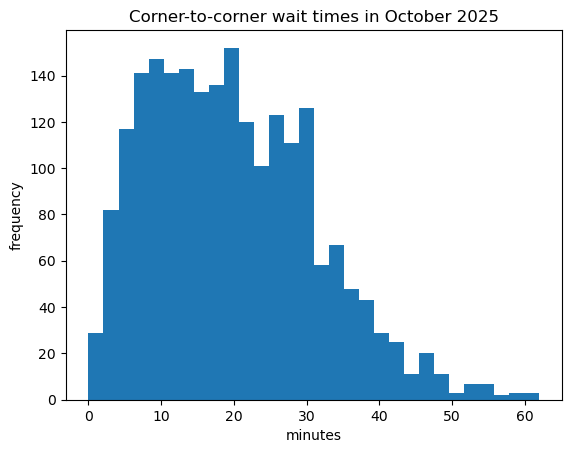

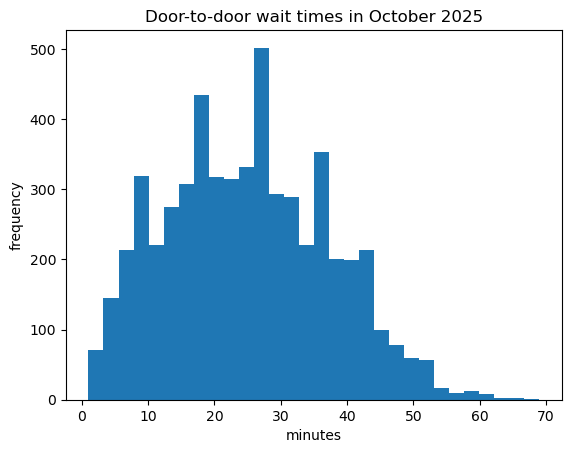

In [14]:
plt.hist(corner_wait, bins=30)
plt.title("Corner-to-corner wait times in October 2025")
plt.xlabel("minutes"); plt.ylabel("frequency")
plt.show()

plt.hist(door_wait, bins=30)
plt.title("Door-to-door wait times in October 2025")
plt.xlabel("minutes"); plt.ylabel("frequency")
plt.show()

In [ ]:
# Load CSV
df = pd.read_csv("Ride Requests_2025-11-11-part-2.csv")

# Convert the time columns to datetime
df["Request Creation Time"] = pd.to_datetime(df["Request Creation Time"])
df["Actual Pickup Time"]   = pd.to_datetime(df["Actual Pickup Time"])

# Compute wait time in minutes
df["wait_min"] = (df["Actual Pickup Time"] - df["Request Creation Time"]).dt.total_seconds() / 60

# Filter for date range 
start_date = "2025-10-01"
end_date   = "2025-10-14"

mask = (df["Request Creation Time"] >= start_date) & (df["Request Creation Time"] <= end_date)
df_filtered = df[mask]

# keep only completed rides
completed = df_filtered[df_filtered["Request Status"] == "Completed"].copy()

# get hour of day 
completed["hour"] = completed["Request Creation Time"].dt.hour

# Filter for DOOR-TO-DOOR from 8 PM (20:00) to 3 AM (03:00)
# Because this window spans midnight, we need OR logic:
door_mask = (completed["hour"] >= 20) | (completed["hour"] < 3)

door_only = completed[door_mask]

# descriptive stats
wait = door_only["wait_min"].dropna()

summary = {
    "min": wait.min(),
    "25th percentile": wait.quantile(0.25),
    "median (50th)": wait.quantile(0.50),
    "75th percentile": wait.quantile(0.75),
    "90th percentile": wait.quantile(0.90),
    "max": wait.max(),
    "mean": wait.mean()
}

print("\nObserved Wait Time Summary (Door-to-door | Oct 1–14):")
for k, v in summary.items():
    print(f"{k}: {v:.2f} minutes")

# wait time distirbution for completed rides in month of october for DOOR TO DOOR ONLY


Observed Wait Time Summary (Door-to-door | Oct 1–14):
min: 1.00 minutes
25th percentile: 16.00 minutes
median (50th): 25.00 minutes
75th percentile: 34.00 minutes
90th percentile: 42.00 minutes
max: 69.00 minutes
mean: 25.00 minutes



Corner-to-corner (4pm–8pm) across ALL months / files:
count: 41132.00
min: 0.00
25th: 9.00
median: 15.00
75th: 24.00
90th: 33.00
max: 85.00
mean: 17.41

Door-to-door (8pm–3am) across ALL months / files:
count: 112611.00
min: 0.00
25th: 12.00
median: 20.00
75th: 29.00
90th: 38.00
max: 89.00
mean: 21.49


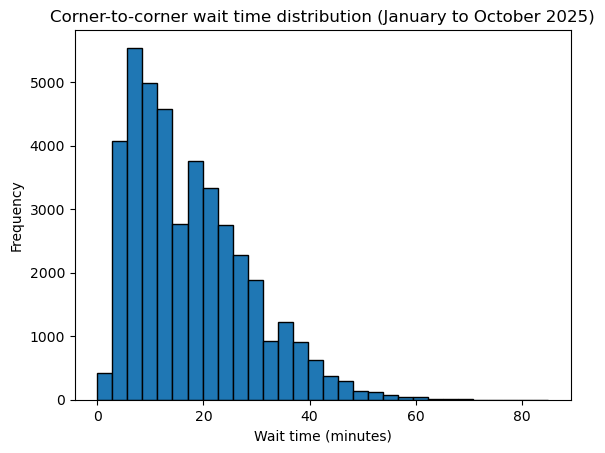

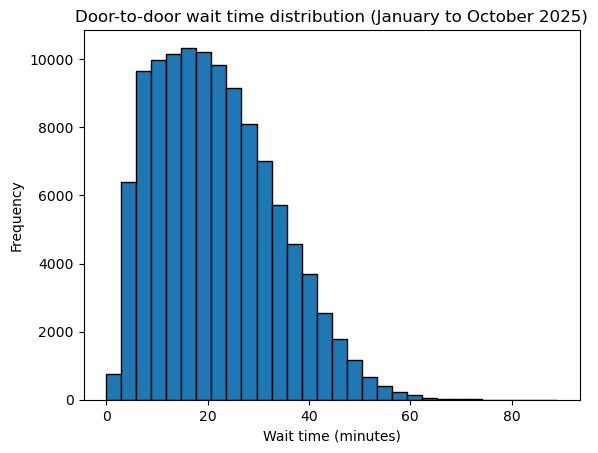

In [ ]:
# ALL RIDE REQUESTS ACROSS ALL OF THE DATA GIVEN NOT JUST OCTOBER 
import pandas as pd
import matplotlib.pyplot as plt

# Read and combine multiple CSVs 
csv_files = [
    "Ride Requests_2025-11-11-part-1.csv",
    "Ride Requests_2025-11-11-part-2.csv"
]

dfs = []
for f in csv_files:
    df = pd.read_csv(f)

    # Convert time columns to datetime
    df["Request Creation Time"] = pd.to_datetime(df["Request Creation Time"])
    df["Actual Pickup Time"]    = pd.to_datetime(df["Actual Pickup Time"])

    # Compute wait time in minutes
    df["wait_min"] = (
        df["Actual Pickup Time"] - df["Request Creation Time"]
    ).dt.total_seconds() / 60

    dfs.append(df)

# Combine all months / files
all_df = pd.concat(dfs, ignore_index=True)

# Keep only completed rides across all months
completed = all_df[all_df["Request Status"] == "Completed"].copy()

# Classify by time of day (corner vs door) 
# Hour (0–23) from request creation time
completed["hour"] = completed["Request Creation Time"].dt.hour

# Corner-to-corner: 4pm (16) <= hour < 8pm (20)
corner_mask = (completed["hour"] >= 16) & (completed["hour"] < 20)

# Door-to-door: 8pm (20) <= hour OR hour < 3am (3)
door_mask   = (completed["hour"] >= 20) | (completed["hour"] < 3)

# label service type
completed["service_type"] = pd.NA
completed.loc[corner_mask, "service_type"] = "corner_to_corner"
completed.loc[door_mask,   "service_type"] = "door_to_door"

# Build wait-time series for each type 
corner_wait = completed.loc[corner_mask, "wait_min"].dropna()
door_wait   = completed.loc[door_mask,   "wait_min"].dropna()

# Summary stats helper 
def summarize_wait(series):
    return {
        "count": len(series),
        "min": series.min(),
        "25th": series.quantile(0.25),
        "median": series.quantile(0.50),
        "75th": series.quantile(0.75),
        "90th": series.quantile(0.90),
        "max": series.max(),
        "mean": series.mean()
    }

corner_summary = summarize_wait(corner_wait)
door_summary   = summarize_wait(door_wait)

print("\nCorner-to-corner (4pm–8pm) across ALL months / files:")
for k, v in corner_summary.items():
    print(f"{k}: {v:.2f}")

print("\nDoor-to-door (8pm–3am) across ALL months / files:")
for k, v in door_summary.items():
    print(f"{k}: {v:.2f}")
    
# Histogram for corner-to-corner
plt.figure()
plt.hist(corner_wait, bins=30, edgecolor="black")
plt.title("Corner-to-corner wait time distribution (January to October 2025)")
plt.xlabel("Wait time (minutes)")
plt.ylabel("Frequency")
plt.show()

# Histogram for door-to-door
plt.figure()
plt.hist(door_wait, bins=30, edgecolor="black")
plt.title("Door-to-door wait time distribution (January to October 2025)")
plt.xlabel("Wait time (minutes)")
plt.ylabel("Frequency")
plt.show()


In [ ]:
# Compute completion rate for service time windows 

# classify all requests (not just completed)
all_df["hour"] = all_df["Request Creation Time"].dt.hour

# corner-to-corner window: 4pm–8pm
corner_mask_all = (all_df["hour"] >= 16) & (all_df["hour"] < 20)

# door-to-door window: 8pm–3am
door_mask_all = (all_df["hour"] >= 20) | (all_df["hour"] < 3)

# get total requests in each window
corner_total = corner_mask_all.sum()
door_total   = door_mask_all.sum()

# completed requests in each window
corner_completed = all_df.loc[corner_mask_all, "Request Status"].eq("Completed").sum()
door_completed   = all_df.loc[door_mask_all,   "Request Status"].eq("Completed").sum()

# compute completion rate (percentage)
corner_completion_rate = corner_completed / corner_total * 100
door_completion_rate   = door_completed / door_total * 100

completion_df = pd.DataFrame({
    "Service Type": ["Corner-to-corner", "Door-to-door"],
    "Total Requests": [corner_total, door_total],
    "Completed Requests": [corner_completed, door_completed],
    "Completion Rate (%)": [corner_completion_rate, door_completion_rate],
})

print(completion_df)


       Service Type  Total Requests  Completed Requests  Completion Rate (%)
0  Corner-to-corner           62711               41132            65.589769
1      Door-to-door          183890              112611            61.238240


In [ ]:
# Compute actual avg ride time from historic data
import pandas as pd

# Load data
df = pd.read_csv("Ride Requests_2025-11-11-part-2.csv")   

# Convert to datetime
df["Request Creation Time"] = pd.to_datetime(df["Request Creation Time"])
df["Actual Pickup Time"]   = pd.to_datetime(df["Actual Pickup Time"])
df["Actual Dropoff Time"]  = pd.to_datetime(df["Actual Dropoff Time"])

# Filtering based on request creation time 

rc = df["Request Creation Time"]

# first 2 weeks of October (Oct 1–14)
oct_mask = (rc.dt.month == 10) & (rc.dt.day <= 14)

# between 8pm and 3am
# hours 20,21,22,23,0,1,2 (3am is treated as cutoff)
hour = rc.dt.hour
time_mask = (hour >= 20) | (hour < 3)

# Completed trips only
status_mask = df["Request Status"] == "Completed"

# Combined mask
mask = oct_mask & time_mask & status_mask

subset = df[mask].copy()

# Compute ride time in minutes 
subset["ride_min"] = (subset["Actual Dropoff Time"] - subset["Actual Pickup Time"]).dt.total_seconds() / 60

avg_ride = subset["ride_min"].mean()

print("Average ride time (Oct 1–14, 8pm–3am, completed):", round(avg_ride, 2), "minutes")

summary = {
    "min": subset["ride_min"].min(),
    "25th": subset["ride_min"].quantile(0.25),
    "median": subset["ride_min"].quantile(0.50),
    "75th": subset["ride_min"].quantile(0.75),
    "90th": subset["ride_min"].quantile(0.90),
    "max": subset["ride_min"].max(),
    "mean": subset["ride_min"].mean(),
}

for k, v in summary.items():
    print(f"{k}: {v:.4f}")


Average ride time (Oct 1–14, 8pm–3am, completed): 8.94 minutes
min: 0.0000
25th: 5.0000
median: 8.0000
75th: 11.0000
90th: 15.0000
max: 56.0000
mean: 8.9442


In [ ]:
# Load CSV
df = pd.read_csv("Ride Requests_2025-11-11-part-2.csv")

# Convert the time columns to datetime
df["Request Creation Time"] = pd.to_datetime(df["Request Creation Time"])
df["Actual Pickup Time"]   = pd.to_datetime(df["Actual Pickup Time"])

# Compute wait time in minutes
df["wait_min"] = (df["Actual Pickup Time"] - df["Request Creation Time"]).dt.total_seconds() / 60

# Filter for date range 
start_date = "2025-10-15"
end_date   = "2025-10-31"

mask = (df["Request Creation Time"] >= start_date) & (df["Request Creation Time"] <= end_date)
df_filtered = df[mask]

# keep only completed rides
completed = df_filtered[df_filtered["Request Status"] == "Completed"].copy()

# Extract hour of day 
completed["hour"] = completed["Request Creation Time"].dt.hour

# fFilter for DOOR-TO-DOOR → 8 PM (20:00) to 3 AM (03:00)
door_mask = (completed["hour"] >= 20) | (completed["hour"] < 3)

door_only = completed[door_mask]

# descriptive stats
wait = door_only["wait_min"].dropna()

summary = {
    "min": wait.min(),
    "25th percentile": wait.quantile(0.25),
    "median (50th)": wait.quantile(0.50),
    "75th percentile": wait.quantile(0.75),
    "90th percentile": wait.quantile(0.90),
    "max": wait.max(),
    "mean": wait.mean()
}

print("\nObserved Wait Time Summary (Door-to-door | Oct 15–31):")
for k, v in summary.items():
    print(f"{k}: {v:.4f} minutes")

# wait time distirbution for completed rides in month of october for DOOR TO DOOR ONLY

/var/folders/1w/bhxr8mlj12765sccmbsksxnr0000gn/T/ipykernel_90121/348743957.py:5: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df["Request Creation Time"] = pd.to_datetime(df["Request Creation Time"])
/var/folders/1w/bhxr8mlj12765sccmbsksxnr0000gn/T/ipykernel_90121/348743957.py:6: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df["Actual Pickup Time"]   = pd.to_datetime(df["Actual Pickup Time"])



Observed Wait Time Summary (Door-to-door | Oct 15–31):
min: 0.0000 minutes
25th percentile: 16.0000 minutes
median (50th): 26.0000 minutes
75th percentile: 36.0000 minutes
90th percentile: 44.0000 minutes
max: 79.0000 minutes
mean: 26.6621 minutes


In [ ]:
# Compute actual avg ride time from historic data oct 15-31
import pandas as pd

# Load data
df = pd.read_csv("Ride Requests_2025-11-11-part-2.csv")   

# Convert to datetime
df["Request Creation Time"] = pd.to_datetime(df["Request Creation Time"])
df["Actual Pickup Time"]   = pd.to_datetime(df["Actual Pickup Time"])
df["Actual Dropoff Time"]  = pd.to_datetime(df["Actual Dropoff Time"])

# Filtering based on Request Creation Time 

rc = df["Request Creation Time"]

# First 2 weeks of October (Oct 1–14)
oct_mask = (rc.dt.month == 10) & (rc.dt.day <= 31) & (rc.dt.day >= 15)

# Between 8pm and 3am

hour = rc.dt.hour
time_mask = (hour >= 20) | (hour < 3)

# Completed trips only
status_mask = df["Request Status"] == "Completed"

# Combined mask
mask = oct_mask & time_mask & status_mask

subset = df[mask].copy()

# Compute ride time in minutes 
subset["ride_min"] = (subset["Actual Dropoff Time"] - subset["Actual Pickup Time"]).dt.total_seconds() / 60

avg_ride = subset["ride_min"].mean()

print("Average ride time (Oct 15-31, 8pm–3am, completed):", round(avg_ride, 2), "minutes")

summary = {
    "min": subset["ride_min"].min(),
    "25th": subset["ride_min"].quantile(0.25),
    "median": subset["ride_min"].quantile(0.50),
    "75th": subset["ride_min"].quantile(0.75),
    "90th": subset["ride_min"].quantile(0.90),
    "max": subset["ride_min"].max(),
    "mean": subset["ride_min"].mean(),
}

for k, v in summary.items():
    print(f"{k}: {v:.4f}")


/var/folders/1w/bhxr8mlj12765sccmbsksxnr0000gn/T/ipykernel_90121/860647305.py:8: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df["Request Creation Time"] = pd.to_datetime(df["Request Creation Time"])
/var/folders/1w/bhxr8mlj12765sccmbsksxnr0000gn/T/ipykernel_90121/860647305.py:9: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df["Actual Pickup Time"]   = pd.to_datetime(df["Actual Pickup Time"])
/var/folders/1w/bhxr8mlj12765sccmbsksxnr0000gn/T/ipykernel_90121/860647305.py:10: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df["Actual Dropoff Time"]  = pd.to_datetime(df["Actual

Average ride time (Oct 15-31, 8pm–3am, completed): 9.19 minutes
min: 0.0000
25th: 6.0000
median: 8.0000
75th: 12.0000
90th: 15.0000
max: 302.0000
mean: 9.1925
